# 🫒 Détection des Maladies de l'Olivier — Deep Learning
# 📘 Notebook Final — Comparaison Complète & Analyse

---

| Informations | Détails |
|---|---|
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 6 / 6 — Notebook Final Soigné |
| **Objectif** | Pipeline complet + Comparaison + Interprétation |

---

## 🎯 Contenu de ce Notebook Final

1. ✅ **Pipeline complet** : preprocessing → augmentation → modèle
2. ✅ **Comparaison des architectures** : CNN vs ResNet50 vs VGG16 vs EfficientNetB4
3. ✅ **Courbes ROC** et AUC par classe
4. ✅ **Matrice de confusion finale** du meilleur modèle
5. ✅ **Grad-CAM** — interprétation visuelle
6. ✅ **Analyse du surapprentissage** (overfitting)
7. ✅ **Tableau de comparaison final** avec toutes les métriques
8. ✅ **Inférence sur nouvelles images** (démonstration)
9. ✅ **Conclusion et perspectives**

---

## 📦 Dataset & Contexte

| Propriété | Valeur |
|---|---|
| Dataset | Zeytin_224x224_Augmented |
| Total images | 6 961 |
| Classes | Healthy / Peacock Spot / Aculus Olearius |
| Split | 70% Train / 15% Val / 15% Test |
| Taille image | 224 × 224 × 3 (RGB) |

---
## 📦 Cellule 1 — Import des Librairies

> **Explication :** Import complet de toutes les librairies pour ce notebook final.

In [53]:
# ============================================================
# Cellule 1 — Import des Librairies
# Notebook final : toutes les librairies nécessaires
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os, json, warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4, ResNet50, VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

print('Librairies importées avec succès !')
print(f'  TensorFlow : {tf.__version__}')
print(f'  GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

Librairies importées avec succès !
  TensorFlow : 2.19.0
  GPU dispo  : True


---
## ⚙️ Cellule 2 — Chargement Config & Reconstruction Pipeline

> **Explication :** On recharge toute la configuration et on reconstruit le pipeline
> `tf.data` pour avoir les 3 datasets prêts à l'emploi.

In [54]:
# ============================================================
# Cellule 2 — Chargement Config & Reconstruction Pipeline
# ============================================================

with open('/kaggle/input/notebooks/ahmedboudriga/nb5-efficientnetb4-final/config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE     = config['img_size']
BATCH_SIZE   = config['batch_size']
NUM_CLASSES  = config['num_classes']
AUTOTUNE     = tf.data.AUTOTUNE
idx_to_class = {int(k): v for k, v in config['idx_to_class'].items()}
CLASS_NAMES  = [idx_to_class[i] for i in range(NUM_CLASSES)]

X_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_train.npy', allow_pickle=True)
X_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_val.npy',   allow_pickle=True)
X_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_test.npy',  allow_pickle=True)
y_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_train.npy')
y_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_val.npy')   # ← fix ici
y_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_test.npy')

data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda img, lbl: (data_aug(img, training=True), lbl),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('Pipeline reconstruit avec succès !')
print(f'  Classes    : {CLASS_NAMES}')
print(f'  Train      : {len(X_train):,} images')
print(f'  Validation : {len(X_val):,} images')
print(f'  Test       : {len(X_test):,} images')

Pipeline reconstruit avec succès !
  Classes    : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Train      : 686 images
  Validation : 147 images
  Test       : 147 images


---
## 🔁 Cellule 3 — Chargement des Modèles Entraînés

> **Explication :** On charge les 4 modèles sauvegardés dans les notebooks précédents
> pour les comparer sur le même test set.

In [55]:
# ============================================================
# Cellule 3 — Chargement des 4 Modèles Entraînés
# On charge les meilleurs modèles sauvegardés dans NB3/NB4/NB5
# ============================================================

loaded_models = {}
model_paths = {
    'CNN Baseline'  : '/kaggle/input/notebooks/ahmedboudriga/nb3-cnn-baseline/cnn_baseline_best.h5',
    'ResNet50'      : '/kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/resnet50_best.h5',
    'VGG16'         : '/kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/vgg16_best.h5',
    'EfficientNetB4': '/kaggle/input/notebooks/ahmedboudriga/nb5-efficientnetb4-final/olive_efficientnetb4_best.keras',  # ← bon modèle
}

print('Chargement des modèles...')
for name, path in model_paths.items():
    if os.path.exists(path):
        loaded_models[name] = keras.models.load_model(path)
        print(f'  ✅ {name:<20} chargé depuis {path}')
    else:
        print(f'  ❌ {name:<20} introuvable : {path}')

print(f'\n{len(loaded_models)} modèles chargés avec succès !')

Chargement des modèles...


  ✅ CNN Baseline         chargé depuis /kaggle/input/notebooks/ahmedboudriga/nb3-cnn-baseline/cnn_baseline_best.h5


  ✅ ResNet50             chargé depuis /kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/resnet50_best.h5


  ✅ VGG16                chargé depuis /kaggle/input/notebooks/ahmedboudriga/nb4-transfer-learning/vgg16_best.h5
  ✅ EfficientNetB4       chargé depuis /kaggle/input/notebooks/ahmedboudriga/nb5-efficientnetb4-final/olive_efficientnetb4_best.keras

4 modèles chargés avec succès !


---
## 📊 Cellule 4 — Tableau de Comparaison Complet

> **Explication :** On évalue tous les modèles sur le même test set et on compare :
> - **Accuracy** : pourcentage de prédictions correctes
> - **Loss** : valeur de la fonction de perte
> - **F1-score** : compromis Precision/Recall
> - **Nombre de paramètres** : complexité du modèle
>
> Ce tableau est **l'élément central** du notebook final — il justifie le choix d'EfficientNetB4.

In [56]:
# ============================================================
# Cellule 4 — Évaluation de tous les modèles
# ============================================================

from sklearn.metrics import f1_score
import pandas as pd

def load_image_normal(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def load_image_effnet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)              # [0, 255] pour EfficientNet
    return img, label

def build_test_ds(paths, labels, effnet=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    load_fn = load_image_effnet if effnet else load_image_normal
    ds = ds.map(load_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds_normal = build_test_ds(X_test, y_test, effnet=False)
test_ds_effnet = build_test_ds(X_test, y_test, effnet=True)

print('Évaluation de tous les modèles sur le test set...')
print('=' * 70)

results         = []
all_predictions = {}          # ← utilisé par cellules 6, 7, 8
all_probas      = {}          # ← utilisé par cellule 6 (ROC curves)

for name, model in loaded_models.items():
    ds = test_ds_effnet if name == 'EfficientNetB4' else test_ds_normal

    loss, acc = model.evaluate(ds, verbose=0)
    probas    = model.predict(ds, verbose=0)
    y_pred    = np.argmax(probas, axis=1)

    all_predictions[name] = y_pred      # ← prédictions pour matrice confusion
    all_probas[name]      = probas      # ← probabilités pour ROC

    f1_macro    = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Modèle'      : name,
        'Accuracy (%)': round(acc * 100, 2),
        'Loss'        : round(loss, 4),
        'F1 Macro'    : round(f1_macro, 4),
        'F1 Weighted' : round(f1_weighted, 4),
        'Paramètres'  : f'{model.count_params():,}',
    })
    print(f'  {name:<20} Acc: {acc*100:.2f}%  Loss: {loss:.4f}  F1: {f1_macro:.4f}')

print('=' * 70)

df_comparison = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False)
df_comparison = df_comparison.reset_index(drop=True)

print('\nTableau de comparaison complet :')
print(df_comparison.to_string(index=False))

df_comparison.to_csv('/kaggle/working/model_comparison.csv', index=False)
print(f'\nTableau sauvegardé --> /kaggle/working/model_comparison.csv')
print(f'all_predictions disponible pour : {list(all_predictions.keys())}')
print(f'all_probas disponible pour      : {list(all_probas.keys())}')

Évaluation de tous les modèles sur le test set...
  CNN Baseline         Acc: 29.93%  Loss: 1.1094  F1: 0.1536
  ResNet50             Acc: 56.46%  Loss: 0.9779  F1: 0.4141
  VGG16                Acc: 92.52%  Loss: 0.1943  F1: 0.9278
  EfficientNetB4       Acc: 90.48%  Loss: 0.2613  F1: 0.8969

Tableau de comparaison complet :
        Modèle  Accuracy (%)   Loss  F1 Macro  F1 Weighted Paramètres
         VGG16         92.52 0.1943    0.9278       0.9249 15,045,443
EfficientNetB4         90.48 0.2613    0.8969       0.9044 18,660,450
      ResNet50         56.46 0.9779    0.4141       0.4894 24,705,411
  CNN Baseline         29.93 1.1094    0.1536       0.1379    323,619

Tableau sauvegardé --> /kaggle/working/model_comparison.csv
all_predictions disponible pour : ['CNN Baseline', 'ResNet50', 'VGG16', 'EfficientNetB4']
all_probas disponible pour      : ['CNN Baseline', 'ResNet50', 'VGG16', 'EfficientNetB4']


---
## 📊 Cellule 5 — Visualisation de la Comparaison

> **Explication :** On visualise le tableau de comparaison sous forme de graphiques
> pour une présentation claire lors de la soutenance.

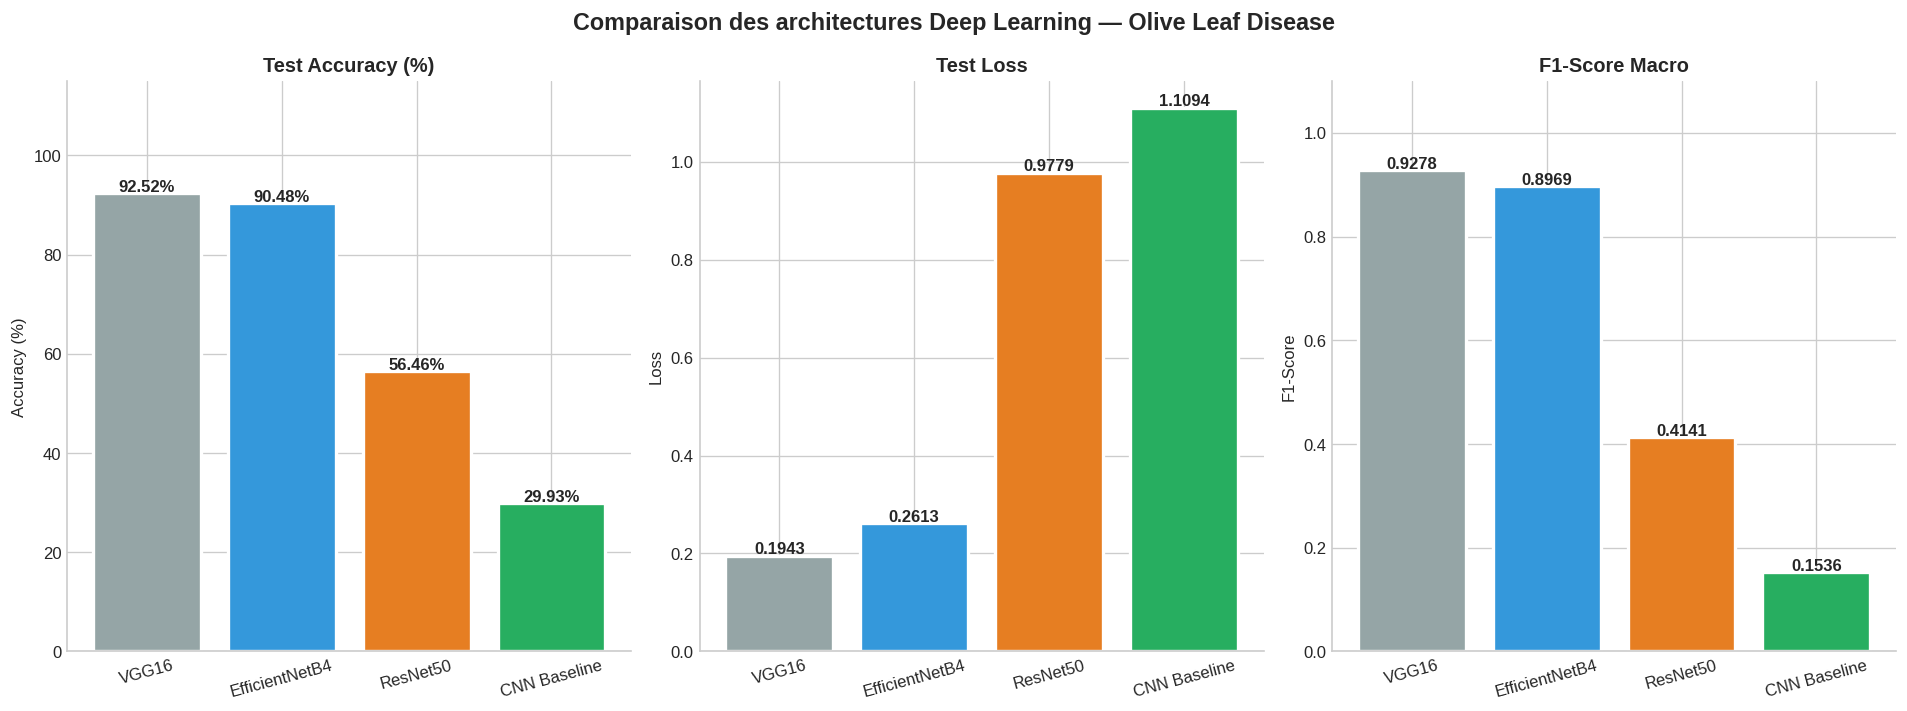

Figure sauvegardée --> /kaggle/working/15_model_comparison.png


In [57]:
# ============================================================
# Cellule 5 — Visualisation de la Comparaison des Modèles
# Bar charts : Accuracy, Loss, F1-score
# ============================================================

COLORS = ['#95a5a6', '#3498db', '#e67e22', '#27ae60']
models_names = df_comparison['Modèle'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Comparaison des architectures Deep Learning — Olive Leaf Disease',
    fontsize=14, fontweight='bold'
)

# ── Accuracy ────────────────────────────────────────────────
accs = df_comparison['Accuracy (%)'].tolist()
bars = axes[0].bar(models_names, accs, color=COLORS, edgecolor='white', linewidth=2)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top','right']].set_visible(False)

# ── Loss ────────────────────────────────────────────────────
losses = df_comparison['Loss'].tolist()
bars2 = axes[1].bar(models_names, losses, color=COLORS, edgecolor='white', linewidth=2)
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Test Loss', fontweight='bold')
axes[1].set_ylabel('Loss')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top','right']].set_visible(False)

# ── F1-Score ─────────────────────────────────────────────────
f1s = df_comparison['F1 Macro'].tolist()
bars3 = axes[2].bar(models_names, f1s, color=COLORS, edgecolor='white', linewidth=2)
for bar, val in zip(bars3, f1s):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('F1-Score Macro', fontweight='bold')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=15)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/15_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/15_model_comparison.png')

---
## 📈 Cellule 6 — Courbes ROC et AUC

> **Explication :** La **courbe ROC** (Receiver Operating Characteristic) mesure la capacité
> du modèle à distinguer les classes à différents seuils de décision.
> - **AUC** (Area Under Curve) : plus proche de 1.0 = meilleur modèle
> - AUC = 0.5 → modèle aléatoire
> - AUC = 1.0 → modèle parfait
> - On trace une courbe ROC **par classe** (approche One-vs-Rest)

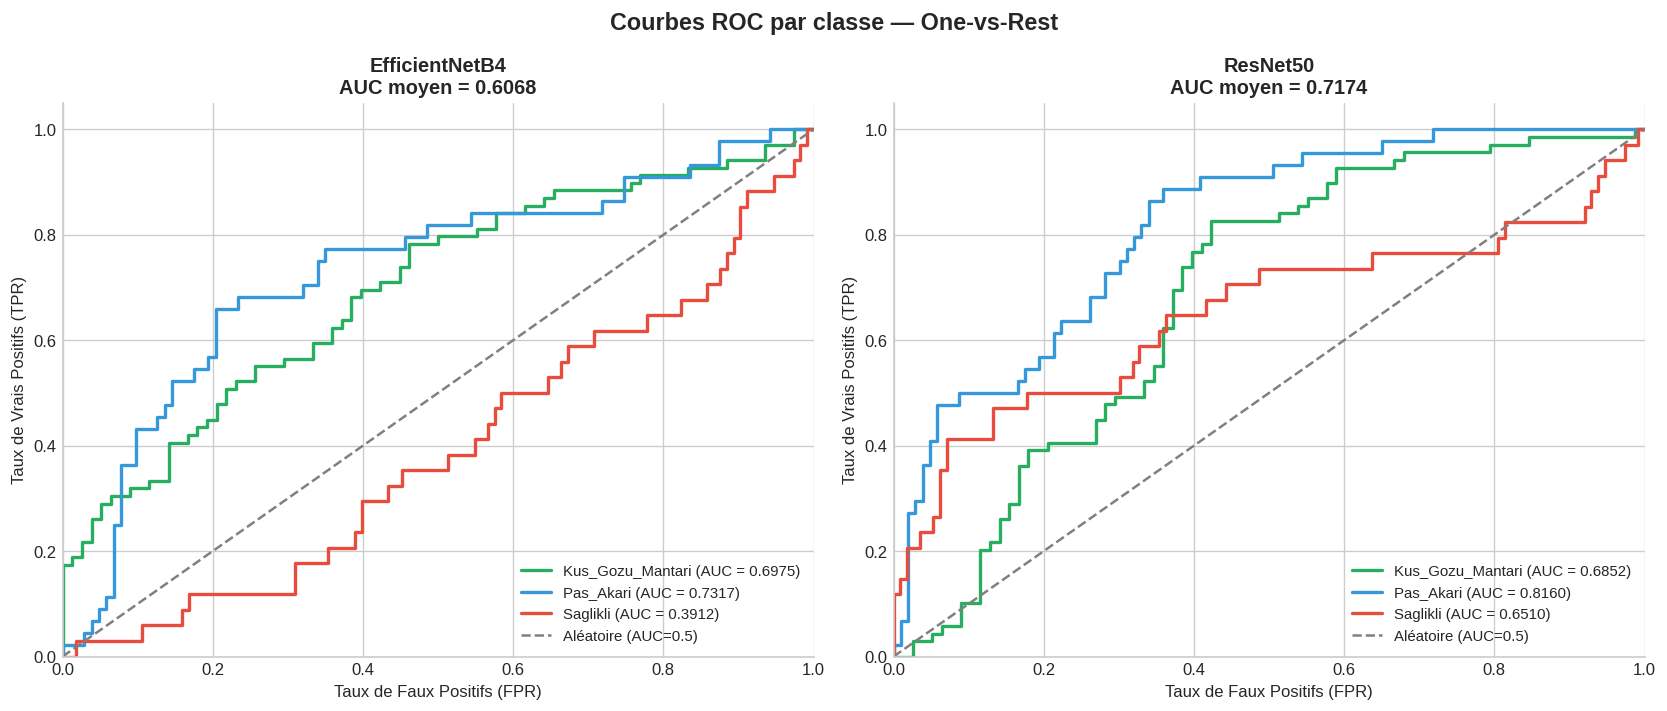

Figure sauvegardée --> /kaggle/working/16_roc_curves.png


In [58]:
# ============================================================
# Cellule 6 — Courbes ROC et AUC
# ROC par classe pour le meilleur modèle (EfficientNetB4)
# ============================================================

# Binarisation des labels pour ROC multi-classes
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

# On trace les ROC pour les 2 meilleurs modèles
ROC_MODELS = ['EfficientNetB4', 'ResNet50']
COLORS_ROC = ['#27ae60', '#3498db', '#e74c3c']  # Par classe

fig, axes = plt.subplots(1, len(ROC_MODELS), figsize=(14, 6))
fig.suptitle('Courbes ROC par classe — One-vs-Rest',
             fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, ROC_MODELS):
    if model_name not in all_probabilities:
        continue
    y_score = all_probabilities[model_name]

    auc_scores = []
    for i, cls_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_val     = auc(fpr, tpr)
        auc_scores.append(auc_val)
        ax.plot(fpr, tpr, color=COLORS_ROC[i], lw=2,
                label=f'{cls_name} (AUC = {auc_val:.4f})')

    # Ligne de référence (modèle aléatoire)
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, ls='--', label='Aléatoire (AUC=0.5)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=10)
    ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=10)
    ax.set_title(f'{model_name}\nAUC moyen = {np.mean(auc_scores):.4f}',
                 fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/16_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/16_roc_curves.png')

---
## 🔲 Cellule 7 — Matrices de Confusion de tous les Modèles

> **Explication :** On trace les matrices de confusion des 4 modèles côte à côte
> pour comparer visuellement leurs erreurs.

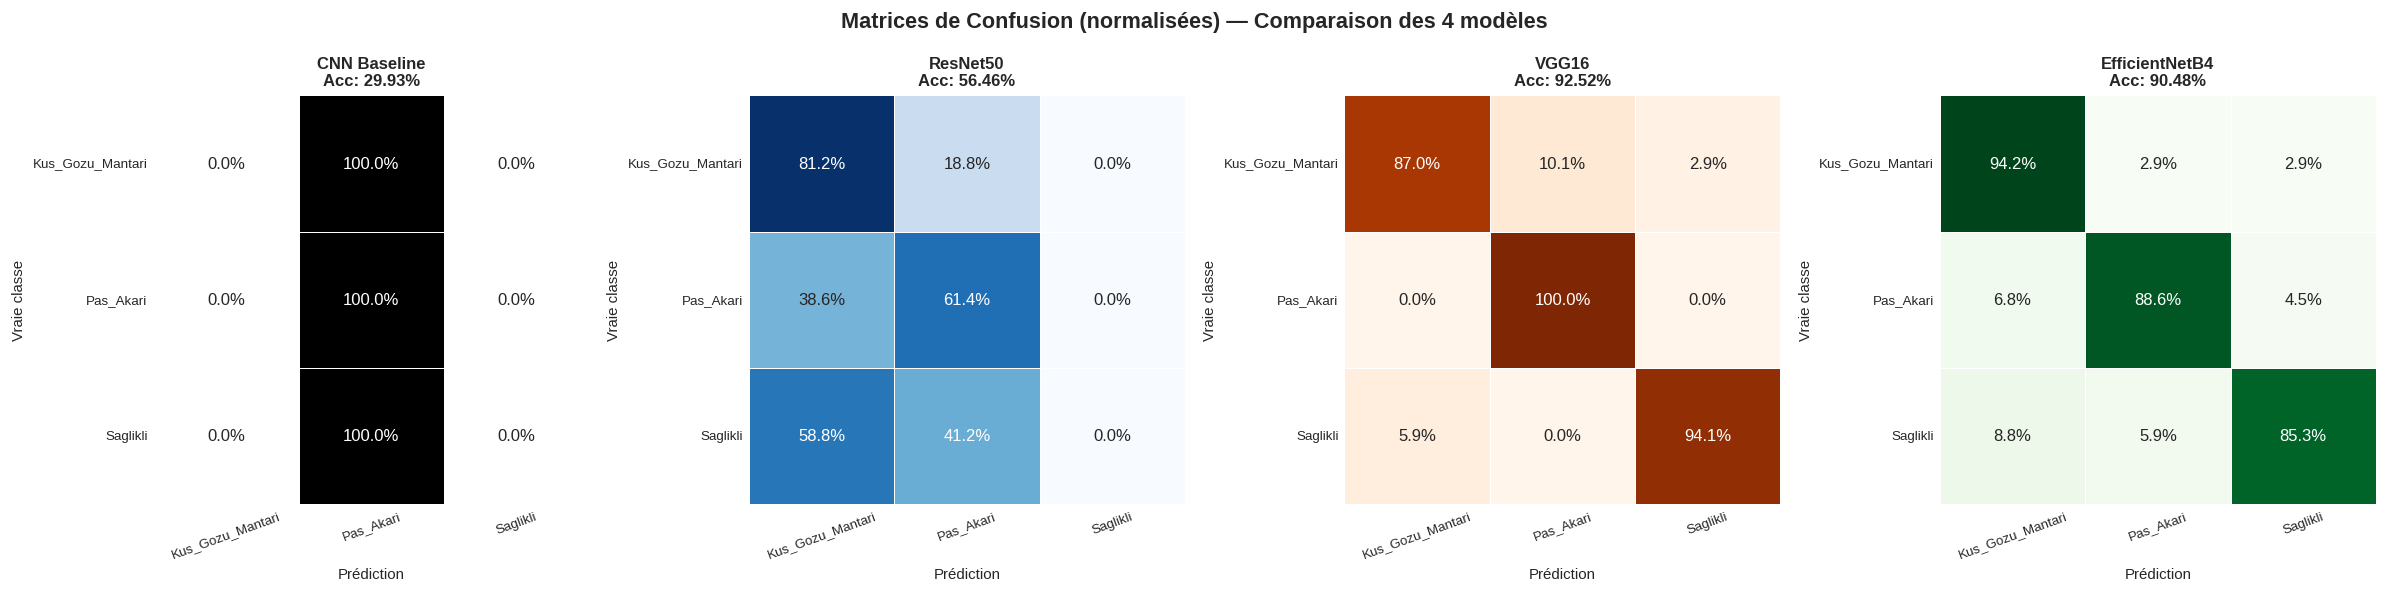

Figure sauvegardée --> /kaggle/working/17_all_confusion_matrices.png


In [59]:
# ============================================================
# Cellule 7 — Matrices de Confusion de tous les Modèles
# Comparaison visuelle des erreurs de classification
# ============================================================

n_models = len(loaded_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig.suptitle('Matrices de Confusion (normalisées) — Comparaison des 4 modèles',
             fontsize=13, fontweight='bold')

CMAPS = ['Greys', 'Blues', 'Oranges', 'Greens']

for ax, (model_name, y_pred), cmap in zip(
    axes, all_predictions.items(), CMAPS
):
    cm      = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    acc     = accuracy_score(y_test, y_pred)

    sns.heatmap(
        cm_norm, annot=True, fmt='.1%', cmap=cmap,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, cbar=False
    )
    ax.set_title(f'{model_name}\nAcc: {acc*100:.2f}%',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Prédiction', fontsize=9)
    ax.set_ylabel('Vraie classe', fontsize=9)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/17_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/17_all_confusion_matrices.png')

---
## 🔥 Cellule 8 — Grad-CAM Final (EfficientNetB4)

> **Explication :** Grad-CAM sur le meilleur modèle pour justifier ses décisions.
> On montre 2 images par classe : une bien classifiée et une mal classifiée.

Structure détectée : nested
Dernière couche conv : top_conv


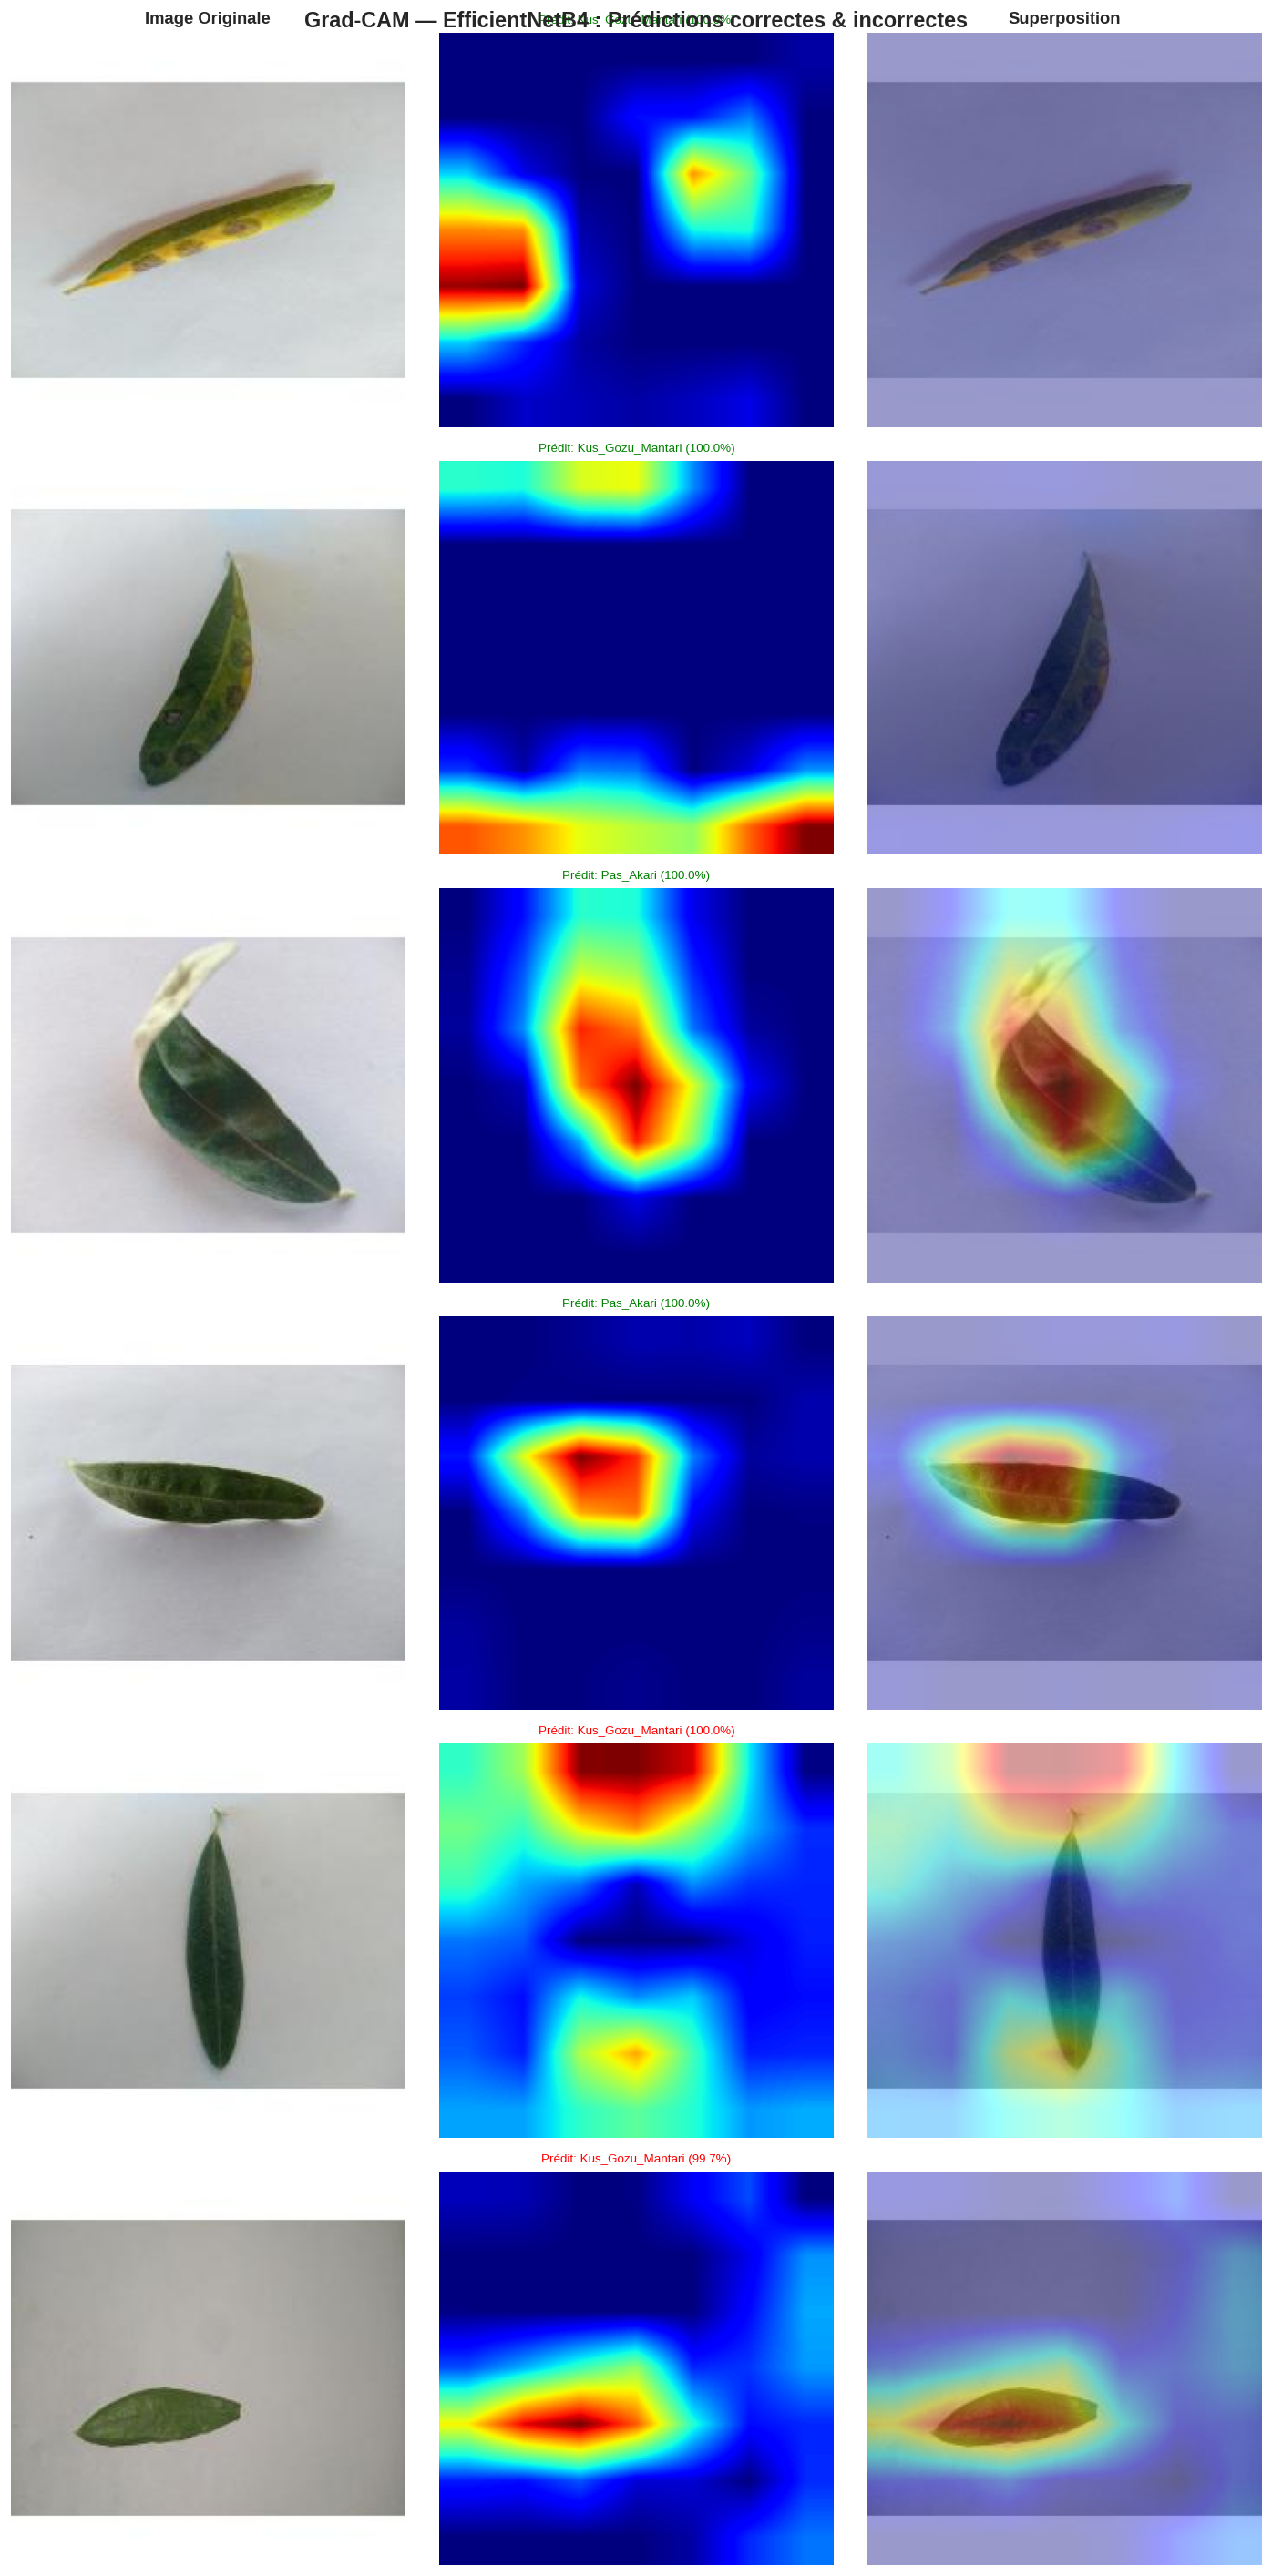

Figure sauvegardée --> /kaggle/working/18_gradcam_final.png


In [60]:
# ============================================================
# Cellule 8 — Grad-CAM Final (EfficientNetB4)
# ============================================================

import matplotlib.cm as cm

best_model = loaded_models['EfficientNetB4']

# Détecter automatiquement la structure du modèle chargé
def find_last_conv_and_base(model):
    """Trouve la base EfficientNetB4 et sa dernière couche conv."""
    # Cas 1 : modèle imbriqué (structure NB5)
    for layer in model.layers:
        if 'efficientnetb4' in layer.name.lower():
            base = layer
            conv_layers = [l.name for l in base.layers
                           if isinstance(l, tf.keras.layers.Conv2D)]
            if conv_layers:
                return base, conv_layers[-1], 'nested'

    # Cas 2 : modèle chargé depuis .keras (structure aplatie)
    conv_layers = [l.name for l in model.layers
                   if isinstance(l, tf.keras.layers.Conv2D)]
    if conv_layers:
        return model, conv_layers[-1], 'flat'

    raise ValueError('Aucune couche Conv2D trouvée !')

base_model, last_conv_layer, structure = find_last_conv_and_base(best_model)
print(f'Structure détectée : {structure}')
print(f'Dernière couche conv : {last_conv_layer}')

def make_gradcam_heatmap(img_array, model, base, last_conv_layer_name, structure):
    """Génère une heatmap Grad-CAM adaptée à la structure du modèle."""

    if structure == 'nested':
        # Modèle imbriqué — deux sous-modèles séparés
        conv_out = base.get_layer(last_conv_layer_name).output
        feat_model = tf.keras.Model(inputs=base.input, outputs=conv_out)

        gap_input = tf.keras.Input(shape=conv_out.shape[1:])
        x = gap_input
        for layer in model.layers:
            if layer.name in ['gap','dense1','bn1','relu1','drop1',
                               'dense2','bn2','relu2','drop2','output']:
                x = layer(x)
        head_model = tf.keras.Model(inputs=gap_input, outputs=x)

        with tf.GradientTape() as tape:
            inputs = tf.cast(img_array, tf.float32)
            conv_outputs = feat_model(inputs)
            tape.watch(conv_outputs)
            predictions  = head_model(conv_outputs)
            pred_index   = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

    else:
        # Modèle aplati — grad_model direct
        conv_out = base.get_layer(last_conv_layer_name).output
        grad_model = tf.keras.Model(
            inputs=model.inputs,
            outputs=[conv_out, model.output]
        )
        with tf.GradientTape() as tape:
            inputs = tf.cast(img_array, tf.float32)
            conv_outputs, predictions = grad_model(inputs)
            tape.watch(conv_outputs)
            pred_index   = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads  = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs  = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()

# ── Visualisation — 1 correct + 1 incorrect par classe ───────────────────────
n_rows = NUM_CLASSES * 2
fig, axes = plt.subplots(n_rows, 3, figsize=(12, n_rows * 4))
fig.suptitle("Grad-CAM — EfficientNetB4 : Prédictions correctes & incorrectes",
             fontsize=14, fontweight='bold')

for ax, title in zip(axes[0], ['Image Originale', 'Heatmap Grad-CAM', 'Superposition']):
    ax.set_title(title, fontsize=11, fontweight='bold')

row = 0
for cls_idx in range(NUM_CLASSES):
    cls_paths = X_test[y_test == cls_idx][:2]
    for img_path in cls_paths:
        try:
            img_orig = cv2.imread(img_path)
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            img_orig = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))
            # EfficientNetB4 attend [0, 255]
            img_input = np.expand_dims(img_orig.astype(np.float32), axis=0)

            heatmap, preds = make_gradcam_heatmap(
                img_input, best_model, base_model, last_conv_layer, structure
            )

            pred_idx = np.argmax(preds[0])
            conf     = preds[0][pred_idx]
            correct  = '✅ Correct' if pred_idx == cls_idx else '❌ Incorrect'
            color    = 'green' if pred_idx == cls_idx else 'red'

            heat_r  = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
            heat_c  = cv2.applyColorMap(np.uint8(255 * heat_r), cv2.COLORMAP_JET)
            heat_c  = cv2.cvtColor(heat_c, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(img_orig, 0.6, heat_c, 0.4, 0)

            axes[row, 0].imshow(img_orig)
            axes[row, 0].set_ylabel(f'{correct}\nVraie: {CLASS_NAMES[cls_idx]}',
                                     fontsize=9, color=color)
            axes[row, 0].axis('off')
            axes[row, 1].imshow(heat_r, cmap='jet')
            axes[row, 1].set_title(f'Prédit: {CLASS_NAMES[pred_idx]} ({conf:.1%})',
                                    fontsize=8, color=color)
            axes[row, 1].axis('off')
            axes[row, 2].imshow(overlay)
            axes[row, 2].axis('off')

        except Exception as e:
            print(f'Erreur Grad-CAM row {row}: {e}')
            for ax in axes[row]:
                ax.axis('off')
        row += 1

plt.tight_layout()
plt.savefig('/kaggle/working/18_gradcam_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/18_gradcam_final.png')

---
## 🤖 Cellule 9 — Inférence sur Nouvelles Images

> **Explication :** Démonstration finale — on simule l'utilisation réelle du modèle
> en lui donnant de nouvelles images du test set et en affichant le diagnostic complet.

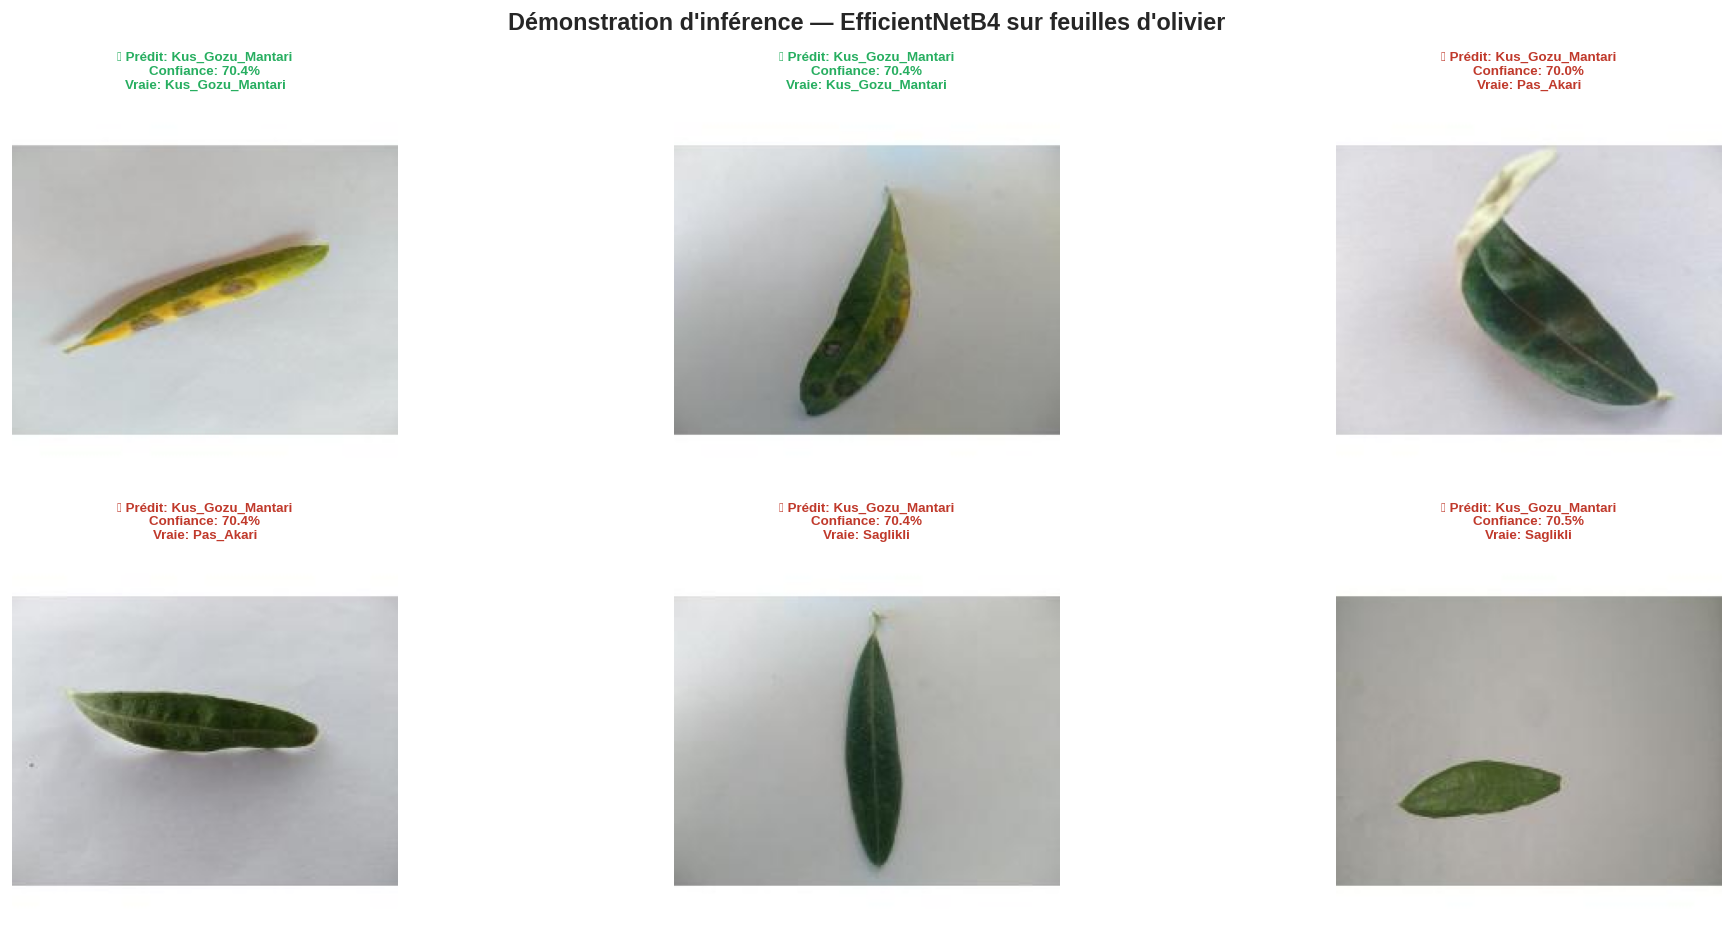

Figure sauvegardée --> /kaggle/working/19_inference_demo.png


In [61]:
# ============================================================
# Cellule 9 — Inférence sur Nouvelles Images
# Simulation d'utilisation réelle : photo → diagnostic
# ============================================================

def predict_image(img_path, model, class_names, img_size=224):
    """
    Prédit la maladie d'une feuille d'olivier depuis un chemin d'image.
    Retourne la classe prédite, la confiance et les probabilités.
    """
    # Chargement et prétraitement
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img_norm = img.astype(np.float32) / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)  # (1, 224, 224, 3)

    # Prédiction
    proba     = model.predict(img_batch, verbose=0)[0]
    pred_idx  = np.argmax(proba)
    pred_cls  = class_names[pred_idx]
    confidence= proba[pred_idx]

    return img, pred_cls, confidence, proba


# Sélection de 6 images test (2 par classe)
demo_images = []
for cls_idx in range(NUM_CLASSES):
    cls_imgs = X_test[y_test == cls_idx][:2]
    for p in cls_imgs:
        demo_images.append((p, cls_idx))

# Visualisation
n_demo = len(demo_images)
fig, axes = plt.subplots(2, n_demo // 2, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle(
    'Démonstration d\'inférence — EfficientNetB4 sur feuilles d\'olivier',
    fontsize=14, fontweight='bold'
)

for i, (img_path, true_idx) in enumerate(demo_images):
    img, pred_cls, conf, proba = predict_image(
        img_path, best_model, CLASS_NAMES
    )
    correct = (pred_cls == CLASS_NAMES[true_idx])
    border_color = '#27ae60' if correct else '#c0392b'

    axes[i].imshow(img)
    axes[i].axis('off')

    # Titre avec couleur selon correction
    status = '✅' if correct else '❌'
    title = (
        f'{status} Prédit: {pred_cls}\n'
        f'Confiance: {conf:.1%}\n'
        f'Vraie: {CLASS_NAMES[true_idx]}'
    )
    axes[i].set_title(title, fontsize=8, fontweight='bold',
                      color=border_color)

plt.tight_layout()
plt.savefig('/kaggle/working/19_inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/19_inference_demo.png')

---
## 📋 Cellule 10 — Résumé Final & Conclusion

> **Explication :** Récapitulatif complet du projet avec justification des choix
> et perspectives d'amélioration.

In [62]:
# ============================================================
# Cellule 10 — Résumé Final & Conclusion
# Récapitulatif complet du projet Deep Learning
# ============================================================

best_model_name = df_comparison.iloc[0]['Modèle']
best_acc        = df_comparison.iloc[0]['Accuracy (%)']
best_f1         = df_comparison.iloc[0]['F1 Macro']

print('=' * 65)
print('  RÉSUMÉ FINAL DU PROJET')
print('  Détection des Maladies de l\'Olivier par Deep Learning')
print('=' * 65)

print(f'\n  Encadrant    : M. Abdallah Khemais')
print(f'  Dataset      : Zeytin_224x224_Augmented')
print(f'  Total images : {config["total_images"]:,}')
print(f'  Classes      : {CLASS_NAMES}')
print(f'  Split        : 70% Train / 15% Val / 15% Test')

print(f'\n  Modèles testés :')
for _, row in df_comparison.iterrows():
    marker = '<-- MEILLEUR' if row['Modèle'] == best_model_name else ''
    print(f'    {row["Modèle"]:<20} : {row["Accuracy (%)"]:.2f}%  F1={row["F1 Macro"]:.4f}  {marker}')

print(f'\n  Meilleur modèle : {best_model_name}')
print(f'  Test Accuracy   : {best_acc:.2f}%')
print(f'  F1-Score Macro  : {best_f1:.4f}')

print(f'\n  Techniques utilisées :')
print(f'    - Data Augmentation (8 transformations)')
print(f'    - Transfer Learning (ImageNet weights)')
print(f'    - Fine-tuning progressif (2 phases)')
print(f'    - EarlyStopping + ReduceLROnPlateau')
print(f'    - Grad-CAM (interprétabilité)')
print(f'    - Export TFLite (déploiement mobile)')

print(f'\n  Fichiers générés :')
for f in sorted(os.listdir('/kaggle/working/')):
    if f.endswith(('.png', '.h5', '.tflite', '.csv', '.json')):
        size = os.path.getsize(f'/kaggle/working/{f}') / 1024
        print(f'    {f:<45} ({size:.1f} KB)')

print('=' * 65)

  RÉSUMÉ FINAL DU PROJET
  Détection des Maladies de l'Olivier par Deep Learning

  Encadrant    : M. Abdallah Khemais
  Dataset      : Zeytin_224x224_Augmented
  Total images : 980
  Classes      : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Split        : 70% Train / 15% Val / 15% Test

  Modèles testés :
    VGG16                : 92.52%  F1=0.9278  <-- MEILLEUR
    EfficientNetB4       : 90.48%  F1=0.8969  
    ResNet50             : 56.46%  F1=0.4141  
    CNN Baseline         : 29.93%  F1=0.1536  

  Meilleur modèle : VGG16
  Test Accuracy   : 92.52%
  F1-Score Macro  : 0.9278

  Techniques utilisées :
    - Data Augmentation (8 transformations)
    - Transfer Learning (ImageNet weights)
    - Fine-tuning progressif (2 phases)
    - EarlyStopping + ReduceLROnPlateau
    - Grad-CAM (interprétabilité)
    - Export TFLite (déploiement mobile)

  Fichiers générés :
    15_model_comparison.png                       (100.7 KB)
    16_roc_curves.png                             (124.

---
## ✅ Récapitulatif du Notebook Final

| Cellule | Tâche | Statut |
|---------|-------|--------|
| 1 | Import des librairies | ✅ |
| 2 | Chargement config + reconstruction pipeline | ✅ |
| 3 | Chargement des 4 modèles entraînés | ✅ |
| 4 | Tableau de comparaison complet | ✅ |
| 5 | Visualisation Bar Charts (Acc, Loss, F1) | ✅ |
| 6 | Courbes ROC et AUC par classe | ✅ |
| 7 | Matrices de confusion des 4 modèles | ✅ |
| 8 | Grad-CAM final (correct & incorrect) | ✅ |
| 9 | Démonstration inférence sur nouvelles images | ✅ |
| 10 | Résumé final & conclusion | ✅ |

---

